Title : 1D Linear Convection
$$\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = 0$$

In [261]:
import numpy
from matplotlib import pyplot
import time,sys
%matplotlib inline

Block below initializes various parameters of the simulations. 
nx - number of nodes;
dx - distance between two nodes;
nt - number of timesteps;
dt - time interval of each step;
c  - speed of the wave. Since this is linear convections, speed of the wave will be constant

In [262]:
nx = 41
dx = 2 / (nx - 1)
nt = 20
dt = 0.025
c = 1

Initializing the wave. 
Making an array of length equal to the number of nodes and setting value of each node to 1.
Modifying the values of nodes between 0.5 and 1 to 2.


Text(0.5, 1.0, 'Original Wave')

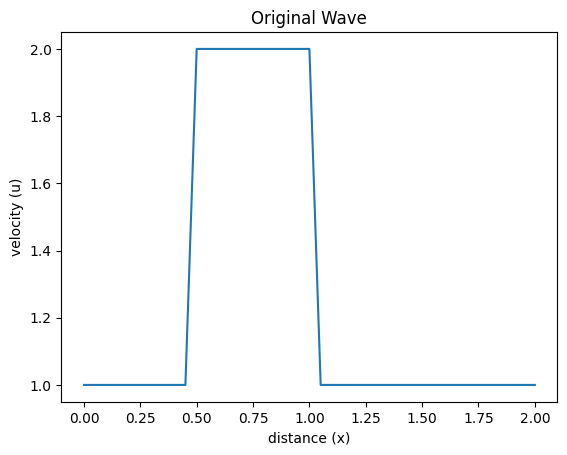

In [263]:
##  The wave considered for this simulation is a square wave.
##  u(x,t) = 2 for 0.5 <= x <= 1
##         = 1 for all other x in between [0,2]



u = numpy.ones(nx)
u[int(.5 / dx):int(1 / dx + 1)] = 2
uorg = u.copy()
pyplot.plot(numpy.linspace(0, 2, nx), u); 
pyplot.xlabel('distance (x)')
pyplot.ylabel('velocity (u)')
pyplot.title('Original Wave')


Simulation logic. Discretization Using Forward Difference in time Domain. Using Backward difference in Space Domain.

Text(0.5, 1.0, 'Simulated wave')

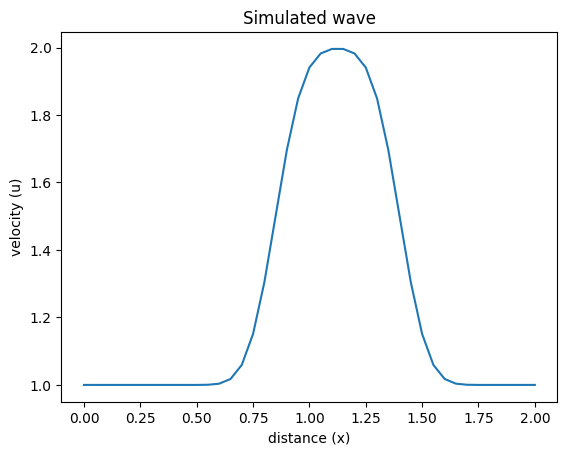

In [264]:
un = numpy.ones(nx) #temporary array 
nt = 15
for n in range(nt):  #loop to run for nt timesteps
    un = u.copy()    #copying original array to temporary
    for i in range(1, nx):
        u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])
u_ftbs = u.copy()
pyplot.plot(numpy.linspace(0, 2, nx), u); 
pyplot.xlabel('distance (x)')
pyplot.ylabel('velocity (u)')
pyplot.title('Simulated wave')


The initial wave has travelled right, as expected. But the sharp edges from original wave have smoothened. This is effect of diffusion which is not present in analytical solution.

This smoothening effect is seen due to "Numerical Diffusion". It can be solved by simulating for courant's number = 1. 

$$Courant's Number = c \frac{\Delta t}{\Delta x}$$

Initially, dt was considered 0.025. Which made courant's number equal to 0.5. It implies, for a single timestep, the wave travels halfway between two nodes. Since a value cannot be stored between two nodes, computer is forced to average value at that point using neighbouring nodes. For courant's number = 1, the wave travels one full grid spacing per timestep instead of halfway between.

$$
u_i^{n+1}=u_i^n-c\left(u_i^n-u_{i-1}^n\right)
$$

This was the discretized equation. We truncated all the non useful Taylor series terms. If we include taylor series terms upto second derivatives and use D'Alembert's wave equation, we arrive at the following equation :

$$\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = \frac{c\Delta x}{2}(1 - \frac{c\Delta t}{\Delta x})\frac{\partial^2 u}{\partial x^2}$$

Because of truncations, this ghost artificial velocity was induced as second derivative diffuse waves. But here if we set courant's number to 1, the entire term on the right hand side collapses to zero, giving us the perfect original equation, we were simulating for. 

Text(0.5, 1.0, "Simulated wave for courant's number = 1")

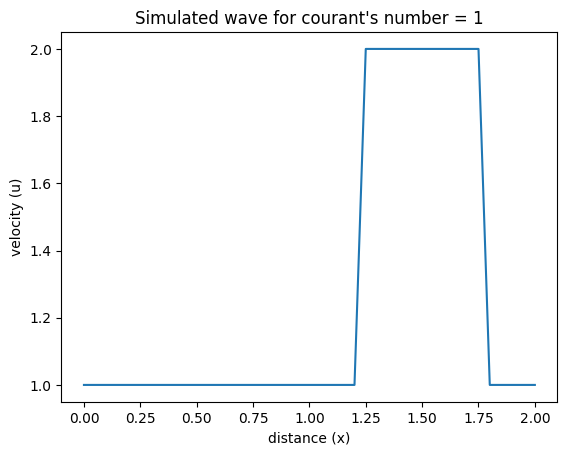

In [265]:
dt = 0.05 ##removes the error
nt = 15
u = numpy.ones(nx)
u[int(.5 / dx):int(1 / dx + 1)] = 2
un = numpy.ones(nx) 

for n in range(nt):  
    un = u.copy() 
    for i in range(1, nx):
        u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])
        
pyplot.plot(numpy.linspace(0, 2, nx), u);
pyplot.xlabel('distance (x)')
pyplot.ylabel('velocity (u)')
pyplot.title('Simulated wave for courant\'s number = 1')


This method of making courant's number = 1 for perfect simulation works only for Linear convection as velocity is constant. For other scenarios, where velocity is changing, the conditions to make courant's number = 1 will vary from node to node. 

Now, using Centred Difference scheme for space discretization:
$$\frac{\partial u}{\partial x} = \frac{u_{i+1}^n - u_{i-1}^n}{2\Delta x} + \frac{\Delta x^2}{6} \frac{\partial^3 u}{\partial x^3} + H.O.T$$

The equation becomes :
$$u_i^{n+1} = u_i^n - c \frac{\Delta t}{\Delta x} \frac{u_{i+1}^n - u_{i-1}^n}{2}$$

Here, the truncated terms of order three of partial derivatives. While even power of derivatives affect the amplitude of the wave, odd powers of derivatives affect phase and positioning of the waves causing dispersion. Since a square wave is made of infinitely many sine waves of different various amplitudes and frequencies, this third derivative will shred all these waves apart and force them to travel at different speeds. It makes the phase velocity of every wave dependent on their amplitude which causes all these waves to seperate and travel at different speeds causing them to lag behind the actual wave.
Also, the second derivative truncated term of the time discretization, appears on the RHS with a negative sign called 'Anti Diffusion'. While positive even powered partial derivatives act as levellers smoothening the waves, negative even powered derivatives, completely mess up the wave by pulling the highs of the wave higher and lows of the wave lower. Causing the lagging waves to errupt in chaotic oscillations.

Text(0.5, 1.0, 'Simulated wave using centered difference')

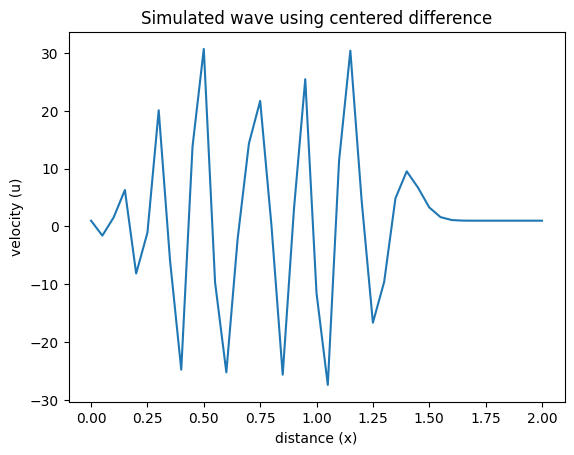

In [266]:
##using centred difference method
nt = 15
u = numpy.ones(nx)
u[int(.5 / dx):int(1 / dx + 1)] = 2
un = numpy.ones(nx) 

for n in range(nt):  
    un = u.copy() 
    for i in range(1, (nx-1)):
        u[i] = un[i] - c * dt / dx * (un[i+1] - un[i-1]) / 2
u_ctrd = u.copy()
pyplot.plot(numpy.linspace(0, 2, nx), u); 
pyplot.xlabel('distance (x)')
pyplot.ylabel('velocity (u)')
pyplot.title('Simulated wave using centered difference')


This can be fixed by Lax Wendroff Scheme.

It includes introducing an artificial viscosity to kill the these chaotics vibrations. The perfect artificial viscosity required can be found out as follows :

$$u_i^{n+1} = u_i^n + \Delta t \frac{\partial u}{\partial t} + \frac {\Delta t^2}{2} \frac{\partial^2 u}{\partial t^2}$$

We know :

$$\frac{\partial u}{\partial t} = -c\frac{\partial u}{\partial x}$$

Hence :

$$\frac{\partial^2 u}{\partial t^2} = c^2\frac{\partial^2 u}{\partial x^2}$$

Equation becomes = 
$$u_i^{n+1} = u_i^n - c\Delta t \frac{\partial u}{\partial x} + \frac {\Delta t^2 c^2}{2} \frac{\partial^2 u}{\partial x^2}$$

This second derivative term is the perfect artificial viscosity we are required to induce to eliminate the errors.

$$\frac {\Delta t^2 c^2}{2} \frac{\partial^2 u}{\partial x^2} = \frac {\Delta t^2 c^2}{2} ( u_{i+1}^n - 2u_i^n + u_{i-1}^n)$$

Adding this in our final Equation : 
$$u_i^{n+1} = u_i^n - c \frac{\Delta t}{\Delta x} \frac{u_{i+1}^n - u_{i-1}^n}{2} + \frac {\Delta t^2 c^2}{2} ( u_{i+1}^n - 2u_i^n + u_{i-1}^n)$$

Text(0.5, 1.0, 'Simulated wave using Lax Wendroff Scheme')

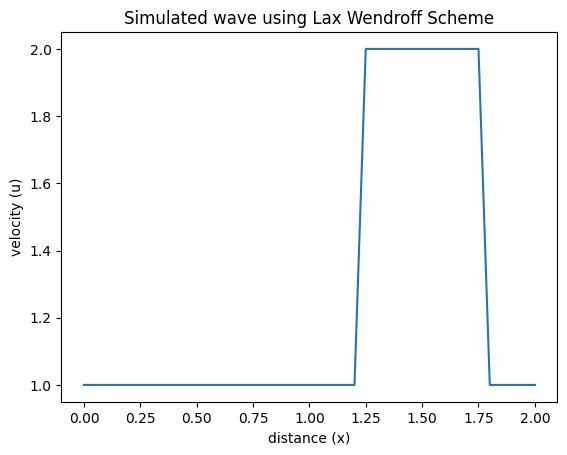

In [267]:
nt = 15
u = numpy.ones(nx)
u[int(.5 / dx):int(1 / dx + 1)] = 2
un = numpy.ones(nx) 

for n in range(nt): 
    un = u.copy() 
    for i in range(1, (nx-1)): 
        u[i] = un[i] - c * dt / dx * (un[i+1] - un[i-1]) / 2 + c*c*dt*dt/(2*dx*dx)*(un[i+1]-2*un[i]+un[i-1])

ulw = u.copy()
pyplot.plot(numpy.linspace(0, 2, nx), u); 
pyplot.xlabel('distance (x)')
pyplot.ylabel('velocity (u)')
pyplot.title('Simulated wave using Lax Wendroff Scheme')


The Lax-Wendroff scheme eliminates numerical diffusion but still exhibits small oscillations near the discontinuity. These dispersive errors arise from the remaining odd-derivative truncation terms. Eliminating these without reintroducing diffusion is solved by advanced schemes.

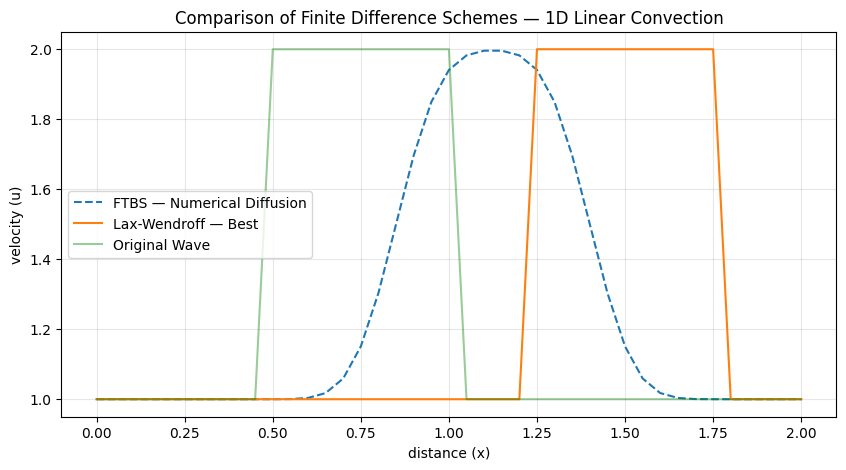

In [ ]:

pyplot.plot(numpy.linspace(0, 2, nx), u_ftbs, label='FTBS — Numerical Diffusion', linestyle='--')
pyplot.plot(numpy.linspace(0, 2, nx), ulw, label='Lax-Wendroff — Best', linestyle='-')
pyplot.plot(numpy.linspace(0, 2, nx), uorg, label='Original Wave', linestyle='-', color='green', alpha=0.4)
pyplot.xlabel('distance (x)')
pyplot.ylabel('velocity (u)')
pyplot.title('Comparison of Finite Difference Schemes — 1D Linear Convection')
pyplot.legend()
pyplot.grid(True, alpha=0.3)